In [1]:
import sys
sys.path.insert(0, '..')

from utils.evaluation import (
    load_and_evaluate_model
)
import pandas as pd
from utils.preprocessing import (
    FEATURES
)

In [2]:
# =========================
# Define datasets
# =========================
df_cicids_combined = pd.read_csv("../data/cicids_combined_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023 = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")

In [3]:
MODEL_TYPES = [
    "mlp", 
    # "cnnlstm"
]
DATASETS = {
    "cicids_combined": {"X": df_cicids_combined[FEATURES], "y": df_cicids_combined["label"]},
    "ciciot2023": {"X": df_ciciot2023[FEATURES], "y": df_ciciot2023["label"]},
}


EVALUATING CICIDS_COMBINED-MLP ON CICIOT2023

=== CICIDS_COMBINED-MLP TESTED ON CICIOT2023 Classification Report ===

                precision    recall  f1-score   support

        ATTACK     0.1240    0.0403    0.0608   1187082
        BENIGN     0.3911    0.7509    0.5144    342255
DDOS_SYN_FLOOD     0.3218    0.9886    0.4856    741270
DDOS_UDP_FLOOD     0.0656    0.0063    0.0115    290106
DOS_HTTP_FLOOD     0.5796    0.0109    0.0213   1508589
      PORTSCAN     0.1850    0.7778    0.2989    216533

      accuracy                         0.2856   4285835
     macro avg     0.2779    0.4291    0.2321   4285835
  weighted avg     0.3391    0.2856    0.1653   4285835

Overall Accuracy: 0.2856

=== Per-Label Accuracy ===

ATTACK: 0.0403
BENIGN: 0.7509
DDOS_SYN_FLOOD: 0.9886
DDOS_UDP_FLOOD: 0.0063
DOS_HTTP_FLOOD: 0.0109
PORTSCAN: 0.7778


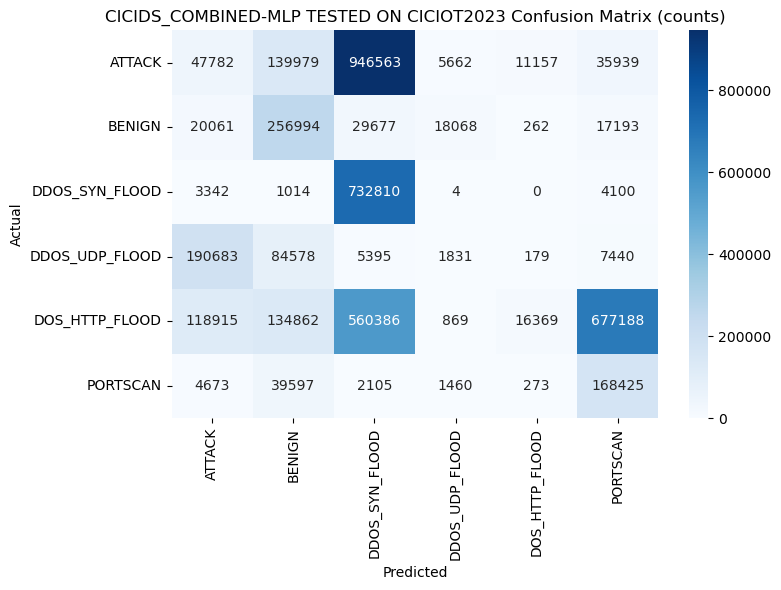


EVALUATING CICIOT2023-MLP ON CICIDS2017

=== CICIOT2023-MLP TESTED ON CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        ATTACK     0.4607    0.6256    0.5306   8869735
        BENIGN     0.9535    0.0189    0.0370   2566701
DDOS_SYN_FLOOD     0.0698    0.0672    0.0685   4337456
DDOS_UDP_FLOOD     0.1923    0.0993    0.1310   1316249
DOS_HTTP_FLOOD     0.4787    0.6930    0.5663    154769
      PORTSCAN     0.6973    0.9947    0.8199    154034

      accuracy                         0.3609  17398944
     macro avg     0.4754    0.4165    0.3589  17398944
  weighted avg     0.4179    0.3609    0.3152  17398944

Overall Accuracy: 0.3609

=== Per-Label Accuracy ===

ATTACK: 0.6256
BENIGN: 0.0189
DDOS_SYN_FLOOD: 0.0672
DDOS_UDP_FLOOD: 0.0993
DOS_HTTP_FLOOD: 0.6930
PORTSCAN: 0.9947


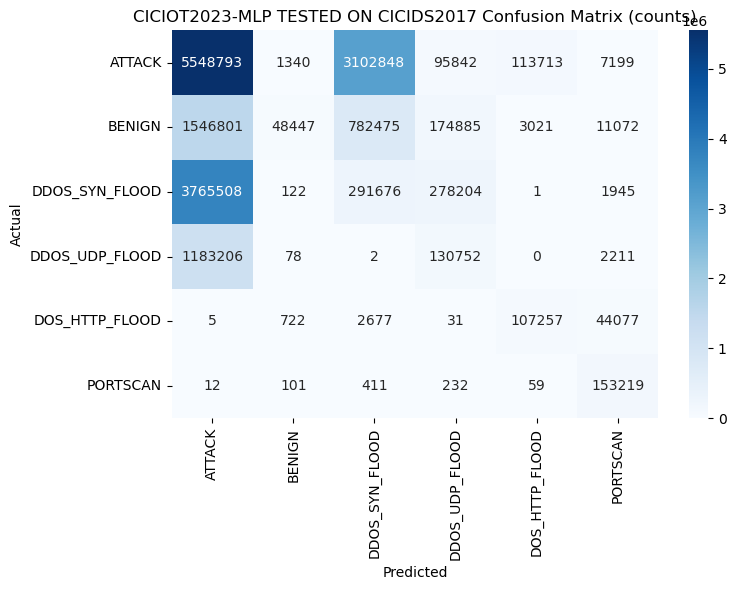

In [ ]:
for MODEL_TYPE in MODEL_TYPES:
    for dataset_name, dataset_config in DATASETS.items():
        if dataset_name == "cicids_combined":
            X_test = DATASETS["ciciot2023"]["X"]
            y_test = DATASETS["ciciot2023"]["y"]
            test_name = "CICIOT2023"
        else:
            X_test = DATASETS["cicids_combined"]["X"]
            y_test = DATASETS["cicids_combined"]["y"]
            test_name = "CICIDS_COMBINED"
        print("\n" + "=" * 70)
        print(f"EVALUATING {dataset_name.upper()}-{MODEL_TYPE.upper()} ON {test_name}")
        print("=" * 70)
        joblib_path = f"models/{MODEL_TYPE}_property_{dataset_name}.joblib"
        load_and_evaluate_model(
            joblib_path=joblib_path,
            X=X_test,
            y_true=y_test,
            model_name=f"{dataset_name.upper()}-{MODEL_TYPE.upper()} TESTED ON {test_name}",
            batch_size=1024
        )